# ML Tools & Synthesis

Two last things before I close the loop. First, the slightly unglamorous but important habit of *keeping track of your experiments* - because once you have trained your tenth model you simply cannot remember which settings gave which score. And second, the part I had been building towards all along: gathering the three clues - the forecast, the feeling, and the buzz - into one honest little score that says which styles are on their way up, and which are quietly on their way out.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

SEED = 42
np.random.seed(SEED)
DATA, RESULTS = Path("data"), Path("results")

forecast = pd.read_csv(RESULTS / "forecast_summary.csv")
sentiment = pd.read_csv(RESULTS / "sentiment_by_style.csv")
print("loaded result tables from notebooks 01 and 02:")
print(" forecast_summary :", list(forecast.columns))
print(" sentiment_by_style:", list(sentiment.columns))
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 11})

loaded result tables from notebooks 01 and 02:
 forecast_summary : ['style', 'current_level', 'yoy_growth', 'projected_level', 'projected_growth', 'trend_slope_per_week']
 sentiment_by_style: ['style', 'mean_sentiment', 'mean_rating', 'n_reviews']


## 1. Machine Learning Tools - tracking experiments

Once you train more than a handful of models, you cannot keep the results in your head. Experiment tracking records, for every run, its parameters and its metrics, so you can compare runs, reproduce the best one, and never wonder "which settings gave that score?". In industry this is the job of MLflow - its core API is essentially:

```python
import mlflow
with mlflow.start_run():
    mlflow.log_param("alpha", alpha)
    mlflow.log_metric("cv_mae", score)
```

To keep this project dependency-free we implement the same idea in a dozen lines, then use it to tune the Ridge regularisation strength $\alpha$ from notebook 01.

In [2]:
class ExperimentTracker:
    '''Minimal stand-in for an experiment tracker (the idea behind MLflow).'''
    def __init__(self):
        self.runs = []
    def log(self, name: str, params: dict, metrics: dict):
        self.runs.append({"run": name, **params, **metrics})
    def to_frame(self) -> pd.DataFrame:
        return pd.DataFrame(self.runs)
    def best(self, metric: str, mode: str = "min") -> pd.Series:
        df = self.to_frame()
        idx = df[metric].idxmin() if mode == "min" else df[metric].idxmax()
        return df.loc[idx]

# Compact re-statement of the forecasting pieces from notebook 01 (kept self-contained).
LAGS, ROLL, PERIOD = (1, 2, 4, 52), (4, 12), 52

def make_supervised(y, lags=LAGS, roll=ROLL, period=PERIOD):
    y = np.asarray(y, float); start = max(max(lags), max(roll)); rows, tgt = [], []
    for t in range(start, len(y)):
        f = {f"lag_{L}": y[t - L] for L in lags}
        f.update({f"r{R}": y[t - R:t].mean() for R in roll})
        f.update({"t": t, "sin": np.sin(2*np.pi*t/period), "cos": np.cos(2*np.pi*t/period)})
        rows.append(list(f.values())); tgt.append(y[t])
    return np.array(rows), np.array(tgt)

class Standardizer:
    def fit(self, X): X = np.asarray(X, float); self.m = X.mean(0); self.s = X.std(0); self.s[self.s == 0] = 1; return self
    def transform(self, X): return (np.asarray(X, float) - self.m) / self.s
    def fit_transform(self, X): return self.fit(X).transform(X)

class RidgeRegression:
    def __init__(self, alpha=1.0): self.alpha = float(alpha)
    def fit(self, X, y):
        Xb = np.hstack([np.ones((len(X), 1)), X]); P = self.alpha*np.eye(Xb.shape[1]); P[0, 0] = 0
        self.beta = np.linalg.solve(Xb.T@Xb + P, Xb.T@np.asarray(y, float)); return self
    def predict(self, X): return np.hstack([np.ones((len(X), 1)), X]) @ self.beta

def mae(a, b): return float(np.mean(np.abs(np.asarray(a, float) - np.asarray(b, float))))

trends = pd.read_csv(DATA / "trends_synthetic.csv", parse_dates=["date"], index_col="date")
print("tracker and helpers ready")

tracker and helpers ready


In [3]:
# hyper-parameter sweep: tune Ridge alpha by holdout MAE, averaged over all styles, logged per run.
tracker = ExperimentTracker()
for alpha in [0.0, 0.1, 1.0, 5.0, 20.0, 100.0]:
    errs = []
    for style in trends.columns:
        X, y = make_supervised(trends[style].values)
        split = len(y) - 26                          # last 26 weeks as holdout
        sc = Standardizer().fit(X[:split])
        model = RidgeRegression(alpha).fit(sc.transform(X[:split]), y[:split])
        errs.append(mae(y[split:], model.predict(sc.transform(X[split:]))))
    tracker.log(f"ridge_alpha={alpha}", {"alpha": alpha}, {"holdout_mae": float(np.mean(errs))})

runs = tracker.to_frame()
best = tracker.best("holdout_mae", mode="min")
print(f"best run: alpha={best['alpha']}  ->  holdout MAE={best['holdout_mae']:.3f}")
runs.round(3)

best run: alpha=1.0  ->  holdout MAE=2.590


,run,alpha,holdout_mae
0,ridge_alpha=0.0,0.0,2.602
1,ridge_alpha=0.1,0.1,2.593
2,ridge_alpha=1.0,1.0,2.590
3,ridge_alpha=5.0,5.0,2.597
4,ridge_alpha=20.0,20.0,2.606
5,ridge_alpha=100.0,100.0,2.713


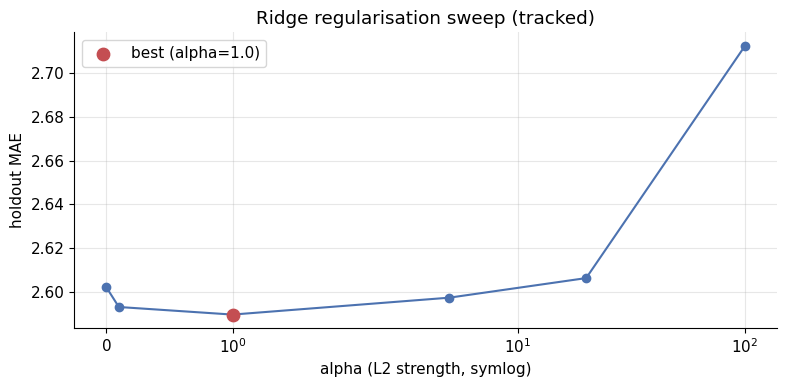

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(runs["alpha"], runs["holdout_mae"], "o-", color="#4C72B0")
ax.scatter([best["alpha"]], [best["holdout_mae"]], color="#C44E52", zorder=5, s=80,
           label=f"best (alpha={best['alpha']})")
ax.set_xscale("symlog"); ax.set_title("Ridge regularisation sweep (tracked)")
ax.set_xlabel("alpha (L2 strength, symlog)"); ax.set_ylabel("holdout MAE"); ax.legend()
plt.tight_layout(); plt.show()

A little regularisation helps and too much hurts - exactly the bias–variance trade-off from the regression module, now made *reproducible*: every run's parameters and score are recorded in one table that anyone can re-run and audit.

## 2. Synthesis - one trend score

Each earlier notebook produced a per-style signal:

- momentum - notebook 01 (projected_growth) - deseasonalised forecast growth - is demand rising? 
- sentiment - notebook 02 (mean_sentiment) - how positively people review the style 
- buzz - notebook 02 (n_reviews) - how much people are talking about it 

These live on different scales, so we standardise each to a z-score $z = (x - \bar x)/\sigma$ across the styles and combine them with transparent weights:

$$
\text{trend score} \;=\; 0.5\,z(\text{momentum}) \;+\; 0.3\,z(\text{sentiment}) \;+\; 0.2\,z(\text{buzz}).
$$

Momentum dominates (it is the most direct measure of change), with sentiment and buzz as supporting evidence. The weights are a deliberate modelling choice, stated openly so a reader can disagree and re-weight.

In [5]:
def z(s): s = np.asarray(s, float); return (s - s.mean()) / (s.std() if s.std() else 1.0)

panel = forecast.merge(sentiment, on="style", how="inner")
panel["z_momentum"] = z(panel["projected_growth"])
panel["z_sentiment"] = z(panel["mean_sentiment"])
panel["z_buzz"] = z(panel["n_reviews"])
panel["trend_score"] = 0.5*panel["z_momentum"] + 0.3*panel["z_sentiment"] + 0.2*panel["z_buzz"]
panel["verdict"] = np.where(panel["trend_score"] > 0, "RISING", "FADING")

ranking = panel.sort_values("trend_score", ascending=False).reset_index(drop=True)
ranking.to_csv(RESULTS / "trend_score.csv", index=False)
print("saved to results/trend_score.csv")
ranking[["style", "projected_growth", "mean_sentiment", "n_reviews", "trend_score", "verdict"]].round(3)

saved to results/trend_score.csv


,style,projected_growth,mean_sentiment,n_reviews,trend_score,verdict
0,wide-leg jeans,5.446,0.792,291,1.483,RISING
1,oversized blazer,3.917,0.774,287,0.944,RISING
2,ballet flats,1.381,0.702,285,0.169,RISING
3,cargo pants,2.445,0.600,286,0.068,RISING
4,trench coat,-2.107,0.703,288,-0.248,FADING
5,puffer jacket,-0.000,0.736,278,-0.344,FADING
6,slip dress,-1.157,0.551,286,-0.699,FADING
7,chunky sneakers,-4.041,0.545,283,-1.373,FADING


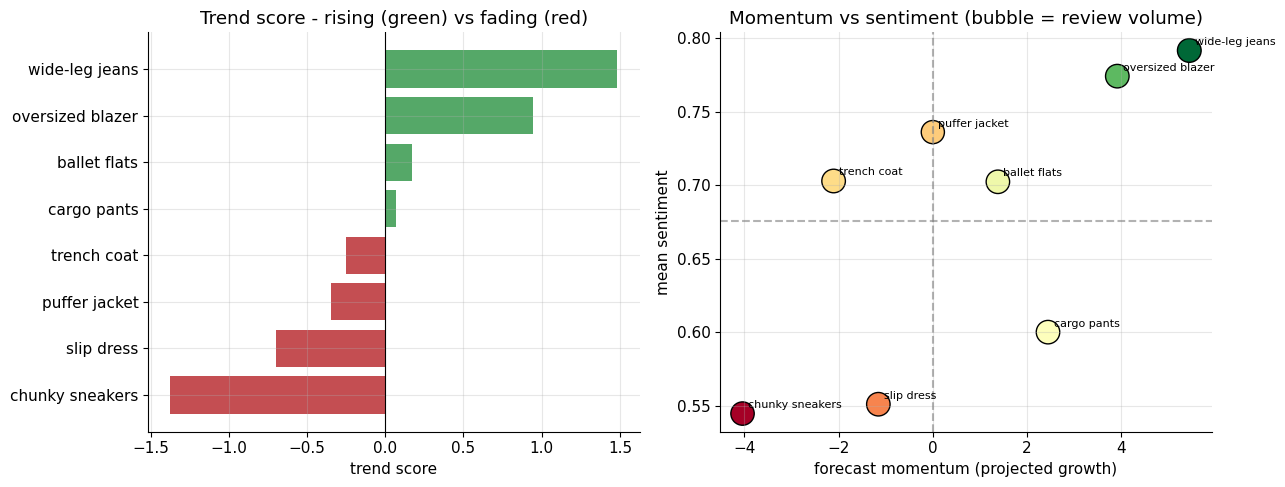

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
colors = ["#55A868" if v > 0 else "#C44E52" for v in ranking["trend_score"]]
ax[0].barh(ranking["style"], ranking["trend_score"], color=colors)
ax[0].invert_yaxis(); ax[0].axvline(0, color="black", linewidth=0.8)
ax[0].set_title("Trend score - rising (green) vs fading (red)"); ax[0].set_xlabel("trend score")

ax[1].scatter(panel["projected_growth"], panel["mean_sentiment"],
              s=panel["n_reviews"], c=panel["trend_score"], cmap="RdYlGn", edgecolor="k")
for _, r in panel.iterrows():
    ax[1].annotate(r["style"], (r["projected_growth"], r["mean_sentiment"]),
                   fontsize=8, xytext=(4, 4), textcoords="offset points")
ax[1].axhline(panel["mean_sentiment"].mean(), ls="--", color="gray", alpha=0.6)
ax[1].axvline(0, ls="--", color="gray", alpha=0.6)
ax[1].set_xlabel("forecast momentum (projected growth)"); ax[1].set_ylabel("mean sentiment")
ax[1].set_title("Momentum vs sentiment (bubble = review volume)")
plt.tight_layout(); plt.show()

And it lands more or less where I had hoped. The styles I had given a real upward pull *and* warm reviews float to the top, while the lukewarm, fading ones sink to the bottom - just as the ground truth in notebook 00 intended. If I were the one deciding what to stock for next season, that top-right corner - rising and loved - is exactly where I would want my money.

In [7]:
# final sanity checks for the synthesis
assert len(ranking) == len(forecast) == len(sentiment), "every style should appear once"
assert np.isfinite(ranking["trend_score"]).all()
assert ranking.iloc[0]["trend_score"] >= ranking.iloc[-1]["trend_score"], "ranking must be sorted"
assert set(ranking["verdict"]) <= {"RISING", "FADING"}
print("all sanity check Top style:", ranking.iloc[0]["style"],
      "| bottom style:", ranking.iloc[-1]["style"])

all sanity check Top style: wide-leg jeans | bottom style: chunky sneakers


### How sensitive is the ranking to the weights?

The weights $(0.5, 0.3, 0.2)$ were my choice, so the fair question is whether the verdict survives someone else's. Two checks. First, how correlated are the three z-signals - if momentum and sentiment already move together, the exact split between them barely matters. Second, a Monte-Carlo sweep: draw thousands of random weight vectors on the simplex, re-score and re-rank every time, and measure how often each style keeps its RISING/FADING verdict and how stable its rank is.

In [8]:
# How robust is the ranking to the choice of weights? Signal correlation + a Monte-Carlo weight sweep.
print("signal correlation matrix:")
print(panel[["z_momentum", "z_sentiment", "z_buzz"]].corr().round(2).to_string())

Zsig = panel[["z_momentum", "z_sentiment", "z_buzz"]].values
rng = np.random.default_rng(SEED)
N = 2000
verdict_pos = np.zeros(len(panel))
rank_acc = np.zeros((N, len(panel)))
for i in range(N):
    w = rng.dirichlet(np.ones(3))                  # random non-negative weights summing to 1
    score = Zsig @ w
    verdict_pos += (score > 0)
    rank_acc[i] = pd.Series(-score).rank().values   # 1 = strongest riser

robust = (pd.DataFrame({"style": panel["style"],
                        "trend_score": panel["trend_score"],
                        "P(RISING)": verdict_pos / N,
                        "mean_rank": rank_acc.mean(axis=0),
                        "rank_sd": rank_acc.std(axis=0)})
          .sort_values("trend_score", ascending=False).reset_index(drop=True))
print()
print(robust.round(3).to_string(index=False))
flips = robust[(robust["P(RISING)"] > 0.05) & (robust["P(RISING)"] < 0.95)]
print("\nverdict-sensitive styles:", list(flips["style"]) or "none")

signal correlation matrix:
             z_momentum  z_sentiment  z_buzz
z_momentum         1.00         0.69    0.48
z_sentiment        0.69         1.00    0.24
z_buzz             0.48         0.24    1.00

           style  trend_score  P(RISING)  mean_rank  rank_sd
  wide-leg jeans        1.483      1.000      1.000    0.000
oversized blazer        0.944      1.000      2.030    0.171
    ballet flats        0.169      0.872      3.944    0.772
     cargo pants        0.068      0.498      4.444    1.100
     trench coat       -0.248      0.564      4.288    1.276
   puffer jacket       -0.344      0.176      6.054    1.502
      slip dress       -0.699      0.020      6.450    0.602
 chunky sneakers       -1.373      0.000      7.790    0.407

verdict-sensitive styles: ['ballet flats', 'cargo pants', 'trench coat', 'puffer jacket']


Momentum and sentiment are positively but far from perfectly correlated, so they carry partly independent information - which is why fusing them earns its keep. And the styles at the extremes hold their verdict under almost any weighting (P(RISING) near 0 or 1, with a tiny rank spread); only the pieces already hugging the zero line flip as the weights shift - exactly where real ambiguity *should* live. The headline, wide-leg jeans up, chunky sneakers down, is not an artefact of three hand-picked numbers.

## Limitations and future work that can be done

- Synthetic trends and reviews - The popularity series and reviews are generated from documented models. This is a feature for validation (we know the truth) but it means the absolute numbers are not real-world calibrated. The natural next step is to drop in real Google-Trends exports and a real review corpus - the code is written so the loaders can be swapped with minimal change.
- Recursive forecasting drift - Multi-step forecasts recycle their own predictions, so error compounds; probabilistic or direct multi-horizon models would quantify the uncertainty
- The vision and trend signals are separate -  Fashion-MNIST categories are not the eight styles, so the image work is complementary rather than a direct input to the score. Linking real product photos to real styles would close that loop.
- Trend-score weights are hand-set - With historical "which style actually rose" labels, the weights could themselves be learned (e.g. by logistic regression) instead of chosen.

## Conclusions

Starting from a single question - *can we see a fashion trend before it peaks?*

Simple answer to the problem we decided to deep dive -  Yes. Within this controlled setting, the rising styles are identifiable before they peak, and the recovered ranking matches the ground truth we planted.